<div style="margin-bottom: 120px;">
    <div style="float:left;">
        <br/>
        <img src="img/udc.png" width="300"/>
    </div>
</div>

<h1 style="color: #d60e8c; text-align:center;">Entrenar y guardar el mejor modelo</h1>

<a name="intro"></a>
<h1 style="color: #d60e8c;">Importamos las librerías</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [26]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import time as clocktime

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn import svm

<a name="dataset"></a>
<h1 style="color: #d60e8c;">Lectura del conjunto de datos</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
path = '/content/drive/MyDrive/Notebooks/puntos_pose/puntos_imgs_sin_v.csv'
#path = 'puntos_imgs_sin_v.csv'

In [29]:
df = pd.read_csv(path)
df.head()

,name,front_left_paw_x,front_left_paw_y,front_left_knee_x,front_left_knee_y,front_left_elbow_x,front_left_elbow_y,rear_left_paw_x,rear_left_paw_y,rear_left_knee_x,...,right_ear_tip_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,withers_x,withers_y,throat_x,throat_y,class
0,n02085620_10074.jpg,0.69520,0.96500,0.66066,0.82400,0.66817,0.67700,0.00000,0.00000,0.0,...,0.06820,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,n02085620_10131.jpg,0.00000,0.00000,0.73502,0.90034,0.73165,0.64646,0.00000,0.00000,0.0,...,0.12733,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,n02085620_1073.jpg,0.00000,0.00000,0.58744,0.96600,0.68792,0.77467,0.00000,0.00000,0.0,...,0.05588,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,n02085620_10976.jpg,0.69876,0.85744,0.63043,0.80096,0.64286,0.67975,0.69876,0.77376,0.0,...,0.24455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,n02085620_11140.jpg,0.79100,0.56133,0.71000,0.55333,0.62600,0.47867,0.00000,0.00000,0.0,...,0.15180,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [30]:
df.shape

(6125, 50)

In [31]:
df['class'].value_counts()

,count
class,
1,3371
0,1454
2,1300


In [32]:
df['class'] = df['class'].map({0: 0, 1: 1, 2: 0})
df['class'].value_counts()

,count
class,
1,3371
0,2754


In [33]:
df['class'].value_counts()

,count
class,
1,3371
0,2754


<a name="division"></a>
<h1 style="color: #d60e8c;">Selección de atributos de entrada y salida</h1>
<hr style="border: 0.5px solid #d60e8c;">


In [34]:
# 30 seleccionadas
feature_df = df[['front_left_paw_x', 'front_left_paw_y', 'front_left_knee_x',
       'front_left_knee_y', 'front_left_elbow_x', 'front_left_elbow_y',
       'rear_left_paw_x', 'rear_left_paw_y', 'rear_left_knee_x',
       'rear_left_knee_y', 'rear_left_elbow_x', 'rear_left_elbow_y',
       'front_right_paw_x', 'front_right_paw_y', 'front_right_knee_x',
       'front_right_knee_y', 'front_right_elbow_x', 'front_right_elbow_y',
       'rear_right_paw_x', 'rear_right_paw_y', 'rear_right_knee_x',
       'rear_right_knee_y', 'rear_right_elbow_x', 'rear_right_elbow_y',
       'chin_x', 'chin_y',
       'tail_start_x', 'tail_start_y', 'withers_x', 'withers_y', 'throat_x', 'throat_y']]
X_orig = np.asarray(feature_df)

In [35]:
y = np.asarray(df[df.columns[len(df.columns)-1]])

<a name="train_test"></a>
<h1 style="color: #d60e8c;">División en datos de entrenamiento y prueba</h1>
<hr style="border: 0.5px solid #d60e8c;">
El siguiente código, utiliza el 80% del conjunto de datos para entrenar el modelo y el 20% para test.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_orig, y, test_size=0.2, random_state = 4, stratify=y)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (4900, 32) (4900,)
Test set: (1225, 32) (1225,)


<a name="scale"></a>
<h1 style="color: #d60e8c;">Escalado de los datos</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [37]:
scaler = preprocessing.StandardScaler()
scaler.fit(X_train) # fit realiza los cálculos y los almacena

X_train = scaler.transform(X_train) # aplica los cálculos sobre el conjunto de datos de entrada para escalarlos
X_test = scaler.transform(X_test)

<a name="crossval"></a>
<h1 style="color: #d60e8c;">Entrenamiento del mejor modelo</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [38]:
kf_sh = StratifiedKFold(n_splits=5, shuffle=True, random_state=0) 

test_sets = []
for train_index, test_index in kf_sh.split(X_train, y_train):
    X_train_split, X_test_split = X_train[train_index], X_train[test_index]
    y_train_split, y_test_split = y_train[train_index], y_train[test_index]
    test_sets.append((X_test_split,y_test_split))

<h2 style="color: #d60e8c;">Modelo 2: MLP - 1 capa - 30 neuronas - batch: 150</h2>

In [39]:
tolerance = 1e-4
iterations = 4000
random_seed = 0
activation_function = 'relu'
batch = 150
layers = (30,)

In [40]:
mlp = MLPClassifier(tol=tolerance, 
                max_iter=iterations, 
                random_state=random_seed,
                activation=activation_function,
                batch_size=batch,
                hidden_layer_sizes=layers
)

res_cv_sh = cross_validate(mlp,X_train,y_train,cv=kf_sh, return_estimator=True, n_jobs=-1)

In [41]:
estimators = res_cv_sh['estimator']   
conf_matrix = []
clf_report = []
for i in range(len(estimators)):
    estimator = estimators[i]
    # Hacemos la predicción con el estimador del split i sobre el conjunto de test del split i
    y_predict = estimator.predict(test_sets[i][0])
    # Valores esperados del conjunto de test del split i
    y_expected = test_sets[i][1]
    # Obtenemos la matriz de confusión y la añadimos a la lista
    conf_matrix.append(confusion_matrix(y_expected, y_predict))
    # Añadimos el classification_report del estimador actual a la lista
    clf_report.append(classification_report(y_expected, y_predict, output_dict=True, zero_division=1))
    print(classification_report(y_expected, y_predict))


              precision    recall  f1-score   support

           0       0.82      0.83      0.82       441
           1       0.86      0.85      0.85       539

    accuracy                           0.84       980
   macro avg       0.84      0.84      0.84       980
weighted avg       0.84      0.84      0.84       980

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       441
           1       0.87      0.85      0.86       539

    accuracy                           0.85       980
   macro avg       0.85      0.85      0.85       980
weighted avg       0.85      0.85      0.85       980

              precision    recall  f1-score   support

           0       0.84      0.85      0.85       441
           1       0.88      0.86      0.87       539

    accuracy                           0.86       980
   macro avg       0.86      0.86      0.86       980
weighted avg       0.86      0.86      0.86       980

              preci

In [42]:
best_estimator_index = 2 # Elegido a mano al ver el classification report
best_estimator = res_cv_sh['estimator'][best_estimator_index]
best_cm = conf_matrix[best_estimator_index]
best_classification_report = clf_report[best_estimator_index]

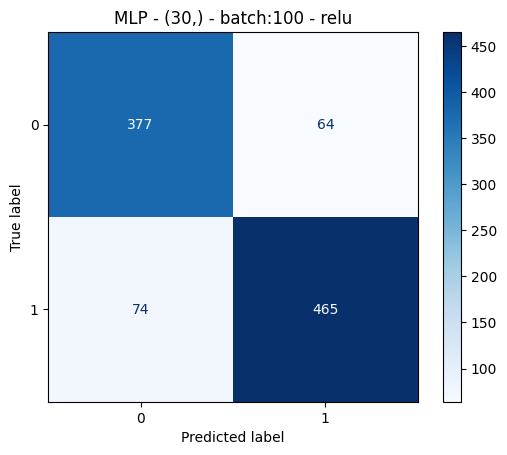

In [43]:
name = "MLP - (30,) - batch:100 - relu"

disp = ConfusionMatrixDisplay(confusion_matrix=best_cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(name)    
plt.savefig(f'matrix_{name}.png',bbox_inches="tight")
plt.show()
plt.close()

### Prueba best estimator con X_test

In [44]:
y_predict = best_estimator.predict(X_test)

In [45]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       551
           1       0.89      0.86      0.87       674

    accuracy                           0.86      1225
   macro avg       0.86      0.86      0.86      1225
weighted avg       0.86      0.86      0.86      1225



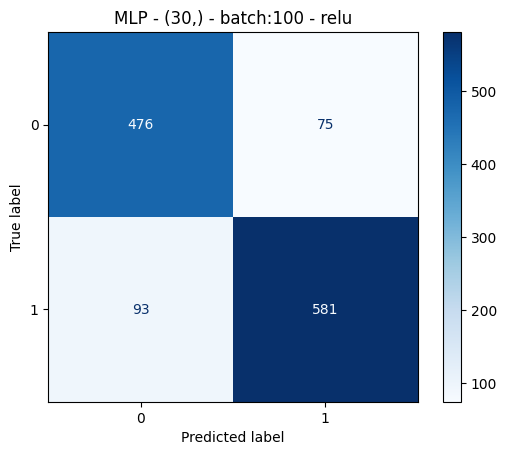

In [46]:
cm = confusion_matrix(y_test, y_predict)

name = "MLP - (30,) - batch:100 - relu"

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(name)    
plt.savefig(f'matrix_{name}.png',bbox_inches="tight")
plt.show()
plt.close()

<a name="save_load"></a>
<h1 style="color: #d60e8c;">Guardar el modelo</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [51]:
from joblib import dump, load

dump(best_estimator, 'best_de_pie_detection.joblib') 

['best_de_pie_detection.joblib']

<br/>
En siguiente bloque de código, carga el modelo guardado previamente y lo utiliza para realizar predicciones:

In [48]:
clf_loaded = load('best_de_pie_detection.joblib') 

In [54]:
[X_test[0]]

[array([ 1.35215517,  0.27199392,  1.07575153,  0.11226512,  1.09074138,
         0.09378483,  0.38834388,  0.82935641, -0.95128519, -1.04672361,
        -0.88211261, -0.91086766,  1.65363934,  0.41990058,  1.42161686,
         0.30578142,  1.12442581,  0.31658389,  0.56743642,  1.05638456,
        -0.7837732 , -1.0026513 , -0.74030808, -0.86001169, -1.84252434,
        -2.24581909, -0.39343374,  2.69613492,  0.        ,  0.        ,
         0.        ,  0.        ])]

In [49]:
datos_predict = X_test[0:10]

y_predict = clf_loaded.predict(datos_predict) # Predicción de los cinco primeros valores del conjunto de datos de test

In [50]:
y_predict

array([0, 0, 1, 1, 0, 0, 0, 0, 0, 1])